In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets

diabetes  = datasets.load_diabetes()
df = pd.DataFrame(data = diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

# check data fram head
print(df.head())

# chack column name
print(df.columns)

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')


target
200.0    6
72.0     6
90.0     5
71.0     5
178.0    5
        ..
146.0    1
212.0    1
120.0    1
183.0    1
57.0     1
Name: count, Length: 214, dtype: int64
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


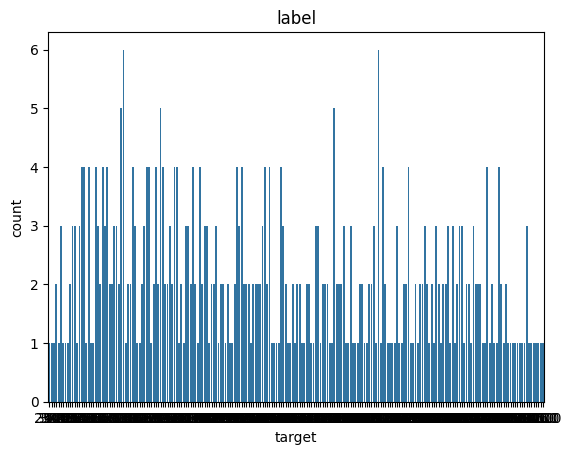

In [2]:
# check label count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x='target')
plt.xlabel = ('Cancer or Not')
plt.ylabel = ('Count')
plt.title('label')

# check count
print(df['target'].value_counts())

# missing values check
print(df.isnull().sum())

In [3]:
# missing values delete
df = df.dropna()
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [4]:
# Feature Selection ( Random Forest by Claude )
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)     # class init
rf.fit(df.drop('target', axis=1), df['target']) # target value delete

importances = pd.Series(rf.feature_importances_, index=df.drop('target', axis=1).columns)
importances.sort_values(ascending=False).head(10)   # 높은 순으로 sort

bmi    0.123988
s5     0.119919
s2     0.117195
s1     0.111698
bp     0.111157
s3     0.110542
s6     0.108900
age    0.108655
s4     0.061189
sex    0.026756
dtype: float64

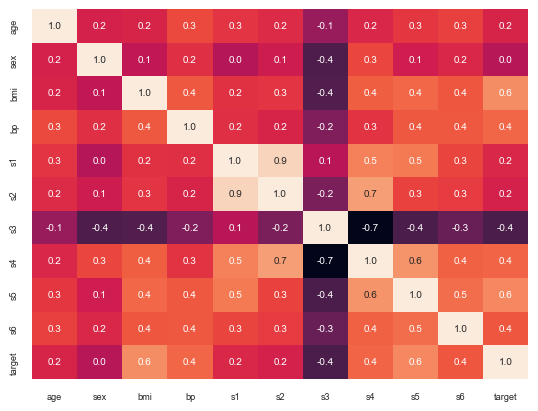

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s3        0.394789
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
Name: target, dtype: float64


In [5]:
# Feature Selection ( Correlation )
import seaborn as sns
import matplotlib.pyplot as plt

#cf = df.drop('target', axis=1) # target value delete
cf = df.copy()
cf_matrix = cf.corr()
plt.Figure(figsize=(15,15))
sns.set(font_scale=0.6)
#sns.heatmap(cf_matrix, annot = True, cbar = False)
sns.heatmap(cf_matrix, annot=True, cbar=False, fmt='.1f')
plt.show()

# sort target by claude 
corr_target = df.corr()['target'].abs().sort_values(ascending=False)
print(corr_target.head(10))

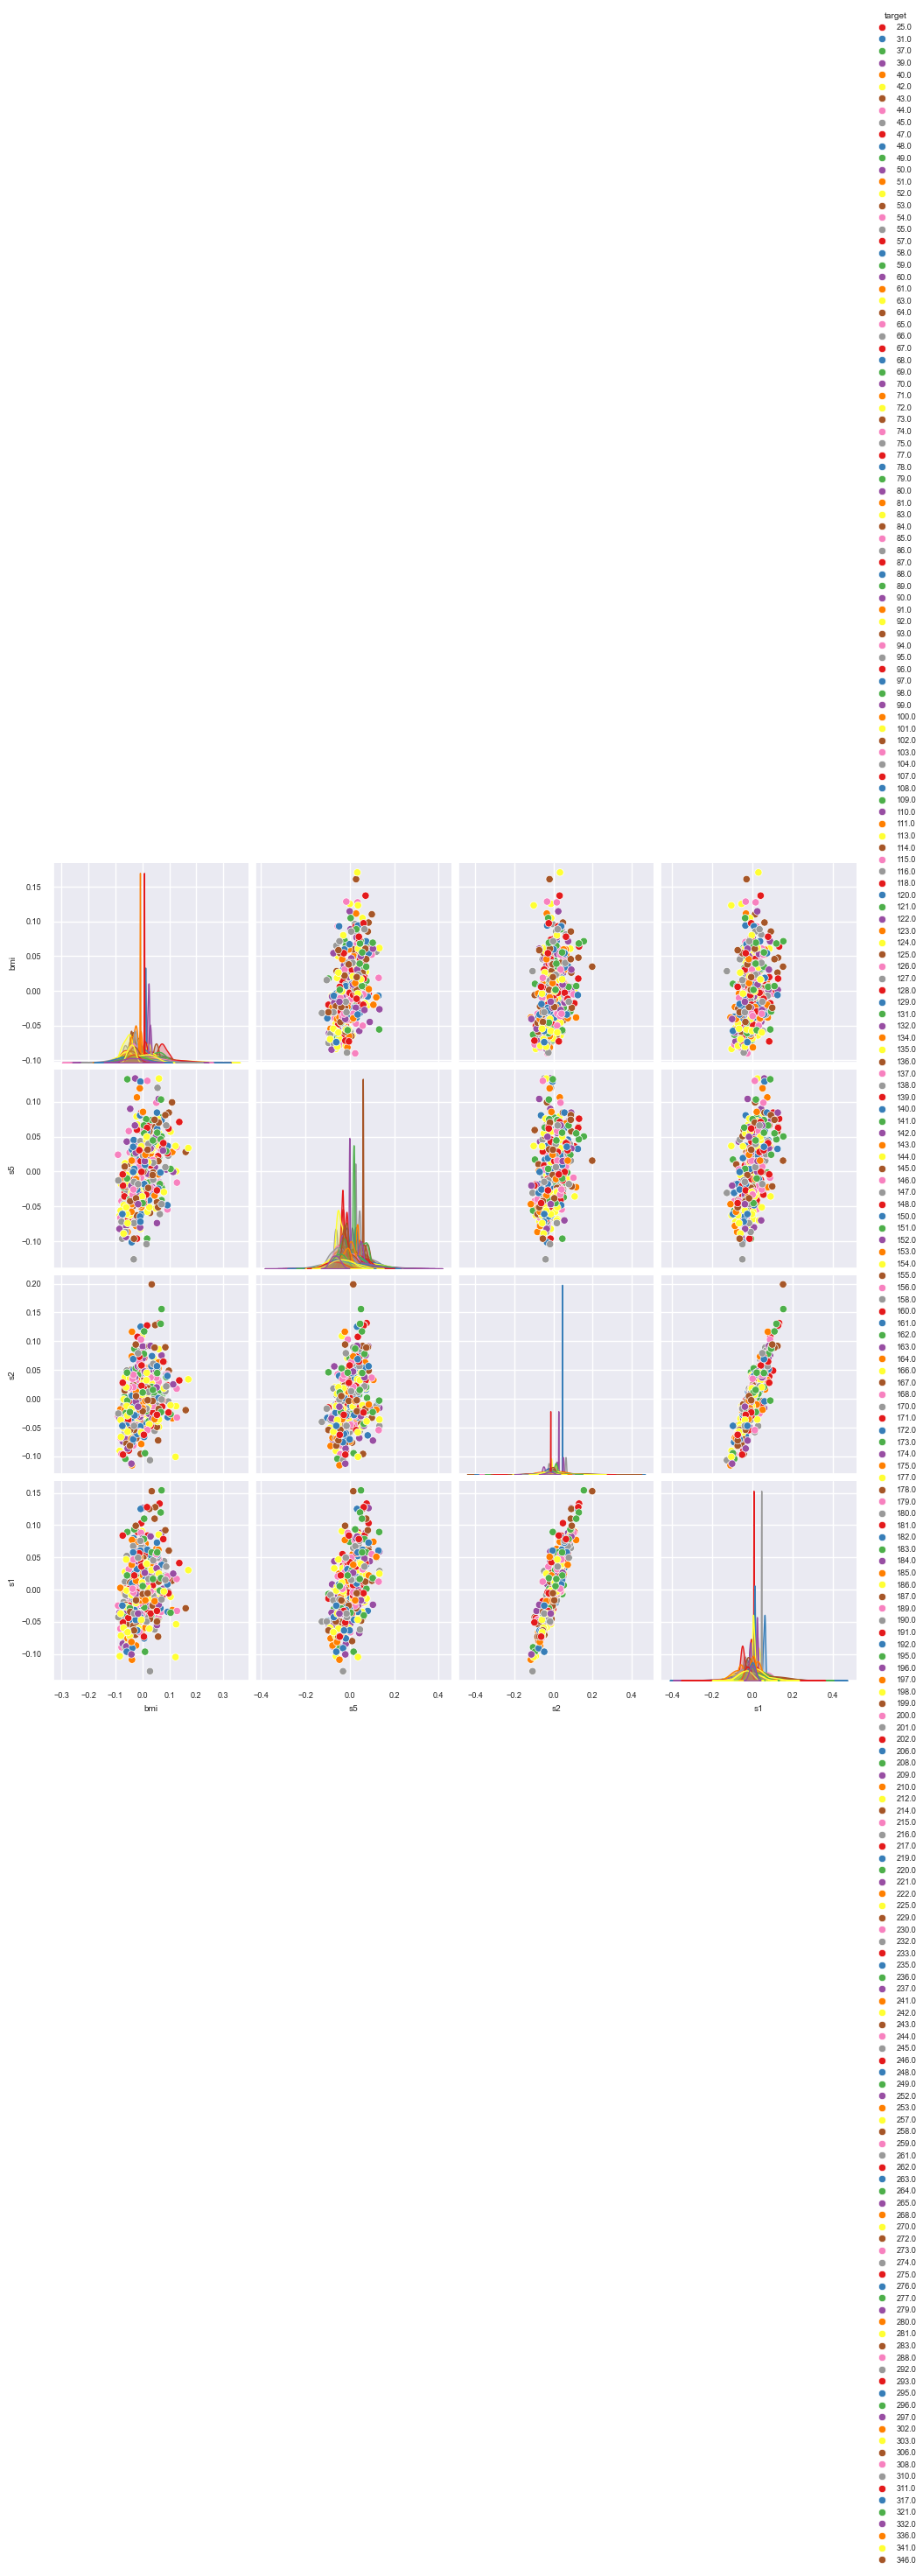

In [ ]:
# check graph ( dataframe is regression so skip this function )
sns.pairplot(df, 
             vars=['bmi','s5', 's2', 's1'], 
             hue='target', 
             palette='Set1',  # 구분이 잘 가는 색상 테마
             diag_kind='kde') # 대각선에는 분포 곡선 표시
plt.show()

# check to target and label data
# 1) missing data check and delete
# 2) Feature selection use to random forest (by claude)
# 3) check graph 
# so) classification 
# so) regression (y = target) -> good target data

In [7]:
# Marchin Learning
# classificatoin
c_df = df.copy()
c_y = c_df['target']
c_x = c_df.drop('target', axis=1)

# regression
r_df = df.copy()
r_y = r_df['target']
r_x = r_df.drop(['target'], axis=1)

# regression
# add standardscaler
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

rx = scaler_x.fit_transform(r_x)
ry = scaler_y.fit_transform(r_y.values.reshape(-1, 1)).flatten()
#d_r_y = r_y.values
#d_r_x = r_x.values

In [42]:
# classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test =  train_test_split(c_x, c_y, test_size=0.2, random_state=0)

c1,c2,c3 = LogisticRegression(random_state=0), DecisionTreeClassifier(random_state=0), RandomForestClassifier(random_state=0)
c1.fit(X_train, y_train); c2.fit(X_train, y_train); c3.fit(X_train,y_train)
c1_y, c2_y, c3_y = c1.predict(X_test), c2.predict(X_test), c3.predict(X_test)

print(f'Logistic Regression \n {classification_report(y_test, c1_y)}')
print(f'Decision Tree \n {classification_report(y_test, c2_y)}')
print(f'Random Forest \n {classification_report(y_test, c3_y)}')


C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could 

Logistic Regression 
               precision    recall  f1-score   support

        47.0       0.00      0.00      0.00       1.0
        49.0       0.00      0.00      0.00       3.0
        52.0       0.00      0.00      0.00       1.0
        53.0       0.00      0.00      0.00       1.0
        57.0       0.00      0.00      0.00       1.0
        59.0       0.00      0.00      0.00       1.0
        61.0       0.00      0.00      0.00       1.0
        64.0       0.00      0.00      0.00       1.0
        67.0       0.00      0.00      0.00       1.0
        68.0       0.00      0.00      0.00       1.0
        72.0       0.00      0.00      0.00       0.0
        74.0       0.00      0.00      0.00       1.0
        75.0       0.00      0.00      0.00       1.0
        84.0       0.00      0.00      0.00       1.0
        86.0       0.00      0.00      0.00       1.0
        88.0       0.00      0.00      0.00       1.0
        89.0       0.00      0.00      0.00       1.0
     

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a r

In [8]:
# regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test =  train_test_split(rx, ry, test_size=0.2, random_state=0)

r1,r2,r3 = LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor()
r1.fit(X_train, y_train); r2.fit(X_train, y_train); r3.fit(X_train,y_train)
r1_y, r2_y, r3_y = r1.predict(X_test), r2.predict(X_test), r3.predict(X_test)

print(f'Linear Regression \n {mean_squared_error(y_test, r1_y)}')
print(f'Decision Tree \n {mean_squared_error(y_test, r2_y)}')
print(f'Random Forest \n {mean_squared_error(y_test, r3_y)}')

Linear Regression 
 0.5774579766434955
Decision Tree 
 1.3944867752364232
Random Forest 
 0.627460696358573


In [ ]:
# Deep Learning

# classification
# One hot incoding
# Comment
# version differenct by claude
# d_c_y = pd.get_dummies(c_y).values
# d_c_x = c_x.values

d_c_y = c_y.values
d_c_x = c_x.values

# regression
# add standardscaler
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

d_r_x = scaler_x.fit_transform(r_x)
d_r_y = scaler_y.fit_transform(r_y.values.reshape(-1, 1)).flatten()
#d_r_y = r_y.values
#d_r_x = r_x.values

print(d_r_y)
print(d_r_x)

[-1.47194752e-02 -1.00165882e+00 -1.44579915e-01  6.99512942e-01
 -2.22496178e-01 -7.15965848e-01 -1.83538046e-01 -1.15749134e+00
 -5.47147277e-01  2.05006151e+00 -6.64021672e-01 -1.07957508e+00
  3.48889755e-01  4.26806019e-01 -4.43258925e-01  2.45001404e-01
  1.80071184e-01 -1.05621783e-01 -7.15965848e-01  2.06043272e-01
 -1.09256112e+00 -1.33929596e+00 -1.09256112e+00  1.20596866e+00
  4.13819975e-01  6.47568766e-01 -1.96524090e-01 -8.71798376e-01
 -2.74440354e-01  1.69943833e+00 -3.00412442e-01 -1.20943552e+00
  2.45262887e+00 -8.45826288e-01 -1.13151925e+00 -6.51035629e-01
  1.46568953e+00  1.60853602e+00  1.29687096e+00 -8.06868156e-01
 -6.77007716e-01 -1.26137969e+00 -1.18346343e+00 -7.80896068e-01
  1.38777327e+00 -1.28735178e+00  4.91736239e-01 -1.31593871e-01
 -1.00165882e+00 -1.31593871e-01  3.72247006e-02  9.46247777e-01
 -1.20943552e+00 -6.25063541e-01  3.87847887e-01 -3.13398486e-01
 -1.30033783e+00 -1.49512849e+00  2.32015360e-01  2.32015360e-01
 -1.18346343e+00 -1.05621

In [15]:
# check input shape
d_c_x.shape[1]

10

In [16]:
# classification
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_c_x,d_c_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(10,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
#model.add(Dense(2,activation='softmax')) # output layer
model.add(Dense(1,activation='sigmoid')) # output layer

model.compile(Adam(learning_rate=0.04), 'binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259 (1.01 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=30,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))          # fitting monitoring

y_pred = model.predict(X_test)

#y_test_class = np.argmax(y_test,axis=1)
#y_pred_class = np.argmax(y_pred,axis=1)

y_pred_class = (y_pred > 0.5).astype(int).flatten()
y_test_class = y_test

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0000e+00 - loss: -256.2197 - val_accuracy: 0.0000e+00 - val_loss: -1198.2943
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -3707.3960 - val_accuracy: 0.0000e+00 - val_loss: -10737.4189
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -24588.5840 - val_accuracy: 0.0000e+00 - val_loss: -58617.7812
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -114731.8203 - val_accuracy: 0.0000e+00 - val_loss: -236618.8750
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -403570.1250 - val_accuracy: 0.0000e+00 - val_loss: -737934.0000
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -1145339.8750 - val_accuracy: 0.0000e+00 - val_loss: -1902853.0000
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: -2743303.2500 - val_accuracy: 0.0000e+00 - val_los

In [18]:
# classification
from sklearn.metrics import classification_report,confusion_matrix

print(f'Deep Learning \n {classification_report(y_test_class, y_pred_class)}')
print(f'Deep Learning \n {confusion_matrix(y_test_class, y_pred_class)}')

Deep Learning 
               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       0.0
        47.0       0.00      0.00      0.00       1.0
        49.0       0.00      0.00      0.00       3.0
        52.0       0.00      0.00      0.00       1.0
        53.0       0.00      0.00      0.00       1.0
        57.0       0.00      0.00      0.00       1.0
        59.0       0.00      0.00      0.00       1.0
        61.0       0.00      0.00      0.00       1.0
        64.0       0.00      0.00      0.00       1.0
        67.0       0.00      0.00      0.00       1.0
        68.0       0.00      0.00      0.00       1.0
        74.0       0.00      0.00      0.00       1.0
        75.0       0.00      0.00      0.00       1.0
        84.0       0.00      0.00      0.00       1.0
        86.0       0.00      0.00      0.00       1.0
        88.0       0.00      0.00      0.00       1.0
        89.0       0.00      0.00      0.00       1.0
        90.

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:

In [19]:
# check input shape
d_r_x.shape[1]

10

In [ ]:
# regression
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_r_x,d_r_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(10,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1)) # output layer

# function information by claude
# rmsprop → 각 파라미터마다 학습률을 다르게 적용
# Adam → rmsprop + momentum 결합, 더 안정적으로 수렴
#model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mse'])


model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259 (1.01 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=100,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))    # fitting monitoring

y_pred = model.predict(X_test)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.0809 - mse: 1.0809 - val_loss: 0.9202 - val_mse: 0.9202
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0424 - mse: 1.0424 - val_loss: 0.8855 - val_mse: 0.8855
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0135 - mse: 1.0135 - val_loss: 0.8592 - val_mse: 0.8592
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9860 - mse: 0.9860 - val_loss: 0.8346 - val_mse: 0.8346
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9560 - mse: 0.9560 - val_loss: 0.8110 - val_mse: 0.8110
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9324 - mse: 0.9324 - val_loss: 0.7885 - val_mse: 0.7885
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9073 - mse: 0.9073 - val_loss: 0.7667 - val_mse: 0.7667
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8772 - mse: 0.8772 - val_loss: 0.7411 - val_mse: 0.7411
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.84

In [22]:
model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6055 - mse: 0.6055


[0.6055141091346741, 0.6055141091346741]

In [23]:
# add regression check by claude 
from sklearn.metrics import mean_squared_error, r2_score

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'Deep Learning MSE:  {mse}')
print(f'Deep Learning RMSE: {rmse}')
print(f'Deep Learning R²:   {r2}')

Deep Learning MSE:  0.6055141135884458
Deep Learning RMSE: 0.7781478738571774
Deep Learning R²:   0.29978937367143244
